# Predictive Maintenance — Phase 1: Define the Problem & Understand the Data

**Project:** Machine Failure Prediction for Industrial Automation  
**Dataset:** AI4I 2020 Predictive Maintenance Dataset (UCI)  
**Goal:** Predict whether a machine will fail based on real-time sensor readings

---

## Problem Statement

Unplanned machine downtime costs manufacturers thousands of dollars per hour.  
This project builds a machine learning model that predicts equipment failure **before it occurs**,  
using real-time sensor data — enabling maintenance teams to act proactively instead of reactively.

**Business question:** Given sensor readings at a point in time, will this machine fail?

**ML framing:** Binary classification → predict `Machine failure` (0 = no failure, 1 = failure)


---
## Step 0 — Install & Import Libraries

In [1]:
# Run this cell once to install everything you need
# (Skip if already installed)
# !pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Make plots look clean and professional
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 1 — Download the Dataset

**Option A (recommended):** Download manually
1. Go to: https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset
2. Download the ZIP file
3. Extract `ai4i2020.csv` and place it in the same folder as this notebook

**Option B:** Download automatically with the cell below

In [3]:
# Option B — auto-download (run only if you haven't downloaded manually)
import urllib.request
import zipfile
import os

url = 'https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip'
zip_path = 'ai4i2020.zip'

if not os.path.exists('ai4i2020.csv'):
    print('Downloading dataset...')
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('.')
    print('Done! File saved as ai4i2020.csv')
else:
    print('Dataset already exists — skipping download.')

Done! File saved as ai4i2020.csv


---
## Step 2 — Load the Data

In [4]:
# Load the CSV into a DataFrame
df = pd.read_csv('ai4i2020.csv')

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
print('First 5 rows:')
df.head()

Dataset shape: 10,000 rows × 14 columns

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


---
## Step 3 — Understand the Columns

Before any analysis, lets read the data dictionary.

| Column | Type | Description |
|---|---|---|
| `UDI` | ID | Row identifier — not useful for modeling |
| `Product ID` | Categorical | Machine quality variant: L (low), M (medium), H (high) |
| `Type` | Categorical | Same as Product ID but letter only — use this one |
| `Air temperature [K]` | Sensor | Ambient air temperature in Kelvin |
| `Process temperature [K]` | Sensor | Machine operating temperature |
| `Rotational speed [rpm]` | Sensor | Motor speed |
| `Torque [Nm]` | Sensor | Rotational force applied |
| `Tool wear [min]` | Sensor | Cumulative time the tool has been in use |
| `Machine failure` | **TARGET** | 1 = failure occurred, 0 = no failure |
| `TWF` | Failure type | Tool Wear Failure |
| `HDF` | Failure type | Heat Dissipation Failure |
| `PWF` | Failure type | Power Failure |
| `OSF` | Failure type | Overstrain Failure |
| `RNF` | Failure type | Random Failure |


In [5]:
# Get data types and non-null counts
print('Column info:')
df.info()
print()

# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values — great!')

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64

In [6]:
# Summary statistics for numeric columns
print('Summary statistics:')
df.describe().round(2)

Summary statistics:


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,300.0,310.01,1538.78,39.99,107.95,0.03,0.00,0.01,0.01,0.01,0.00
std,2886.90,2.0,1.48,179.28,9.97,63.65,0.18,0.07,0.11,0.10,0.10,0.04
min,1.00,295.3,305.70,1168.00,3.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2500.75,298.3,308.80,1423.00,33.20,53.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,5000.50,300.1,310.10,1503.00,40.10,108.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,7500.25,301.5,311.10,1612.00,46.80,162.00,0.00,0.00,0.00,0.00,0.00,0.00
max,10000.00,304.5,313.80,2886.00,76.60,253.00,1.00,1.00,1.00,1.00,1.00,1.00


---
## Step 4 — Understand the Target Variable (Class Imbalance)

In [7]:
# Count failures vs non-failures
counts = df['Machine failure'].value_counts()
pcts   = df['Machine failure'].value_counts(normalize=True) * 100

print('Target variable distribution:')
print(f'  No failure  (0): {counts[0]:,}  ({pcts[0]:.1f}%)')
print(f'  Failure     (1): {counts[1]:,}  ({pcts[1]:.1f}%)')
print()
print('⚠️  CLASS IMBALANCE DETECTED')
print(f'   The dataset has ~{counts[0]//counts[1]}x more non-failures than failures.')
print('   We will handle this in Phase 2 using SMOTE or class_weight parameters.')

Target variable distribution:
  No failure  (0): 9,661  (96.6%)
  Failure     (1): 339  (3.4%)

⚠️  CLASS IMBALANCE DETECTED
   The dataset has ~28x more non-failures than failures.
   We will handle this in Phase 2 using SMOTE or class_weight parameters.


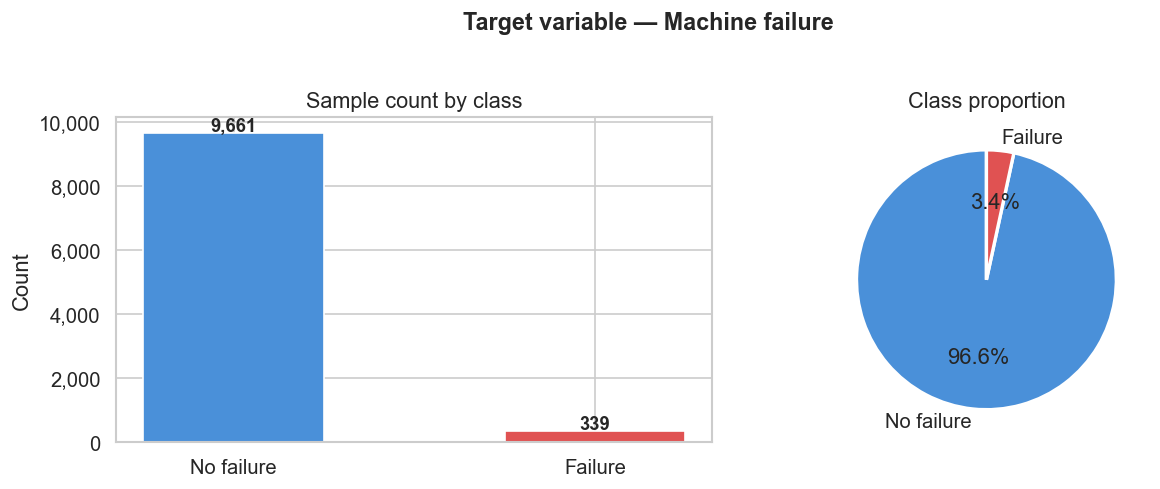

Chart saved as class_distribution.png


In [8]:
# Visualise the class imbalance
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
labels = ['No failure', 'Failure']
colors = ['#4A90D9', '#E05252']
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Sample count by class', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class proportion', fontsize=13)

fig.suptitle('Target variable — Machine failure', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()
print('Chart saved as class_distribution.png')

---
## Step 5 — Explore the Features

In [9]:
# Distribution of the machine quality type (L / M / H)
type_counts = df['Type'].value_counts()
print('Machine types in dataset:')
for t, n in type_counts.items():
    print(f'  {t}: {n:,}  ({n/len(df)*100:.1f}%)')

Machine types in dataset:
  L: 6,000  (60.0%)
  M: 2,997  (30.0%)
  H: 1,003  (10.0%)


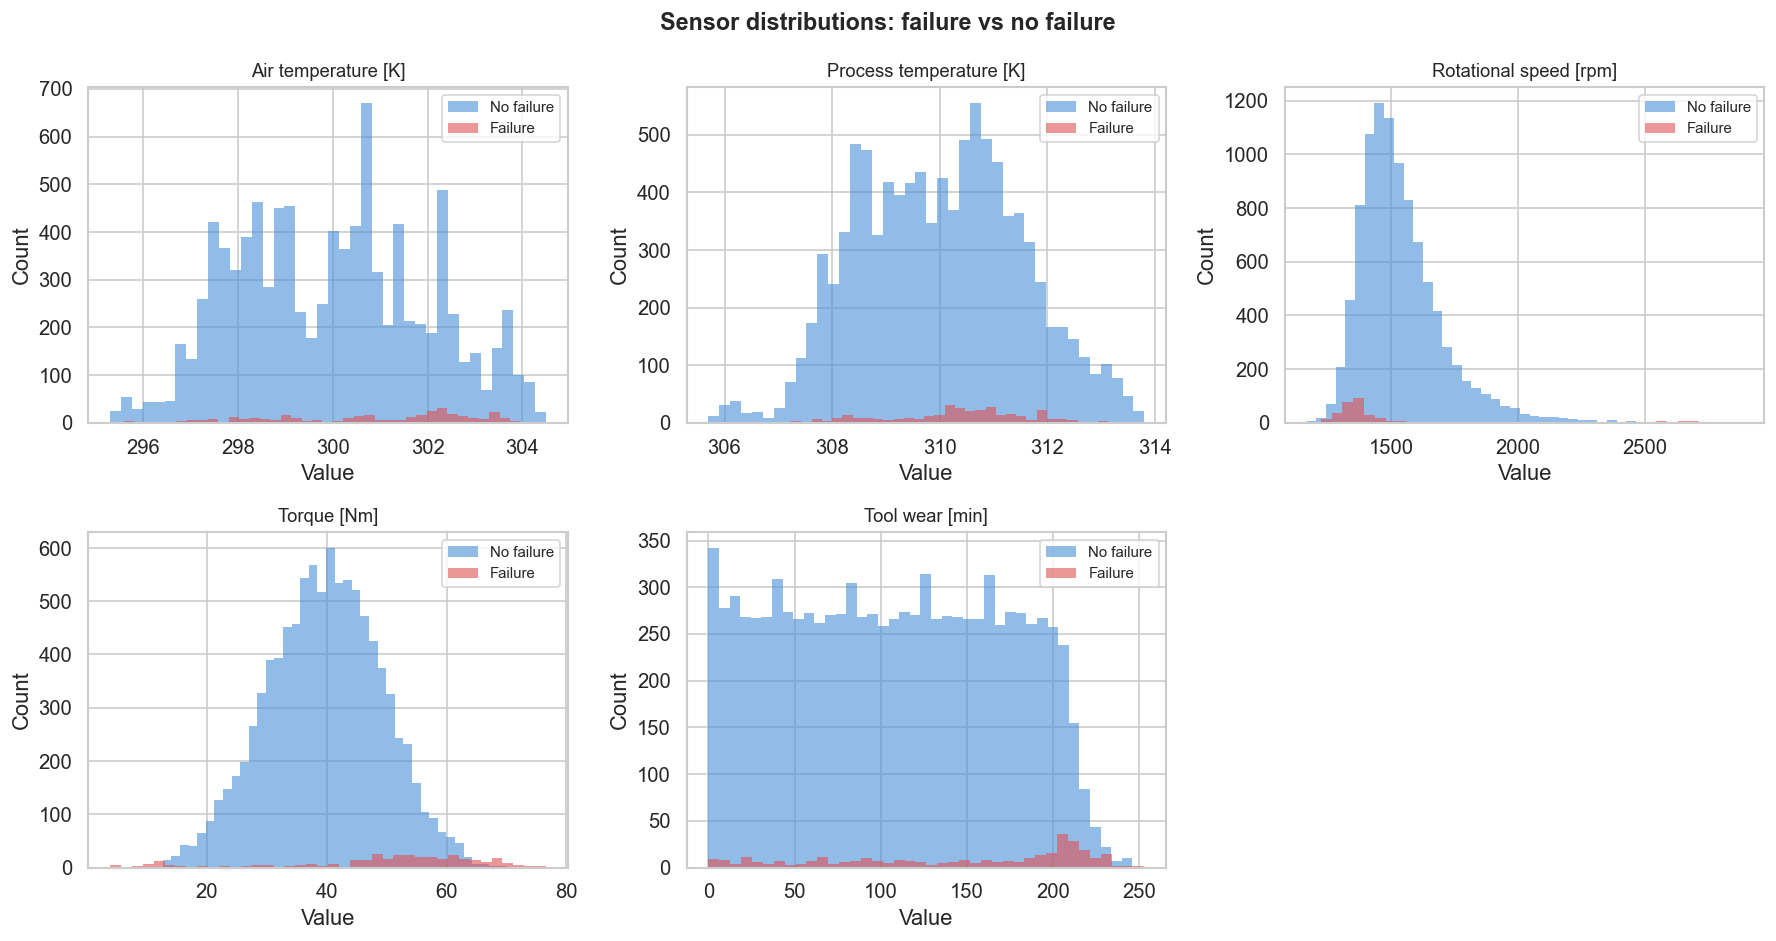

Chart saved as sensor_distributions.png


In [10]:
# Sensor feature distributions — split by failure class
sensor_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    for label, color, name in zip([0, 1], ['#4A90D9', '#E05252'], ['No failure', 'Failure']):
        subset = df[df['Machine failure'] == label][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color, label=name, edgecolor='none')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

# Hide the unused 6th subplot
axes[5].set_visible(False)

fig.suptitle('Sensor distributions: failure vs no failure', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sensor_distributions.png', bbox_inches='tight')
plt.show()
print('Chart saved as sensor_distributions.png')

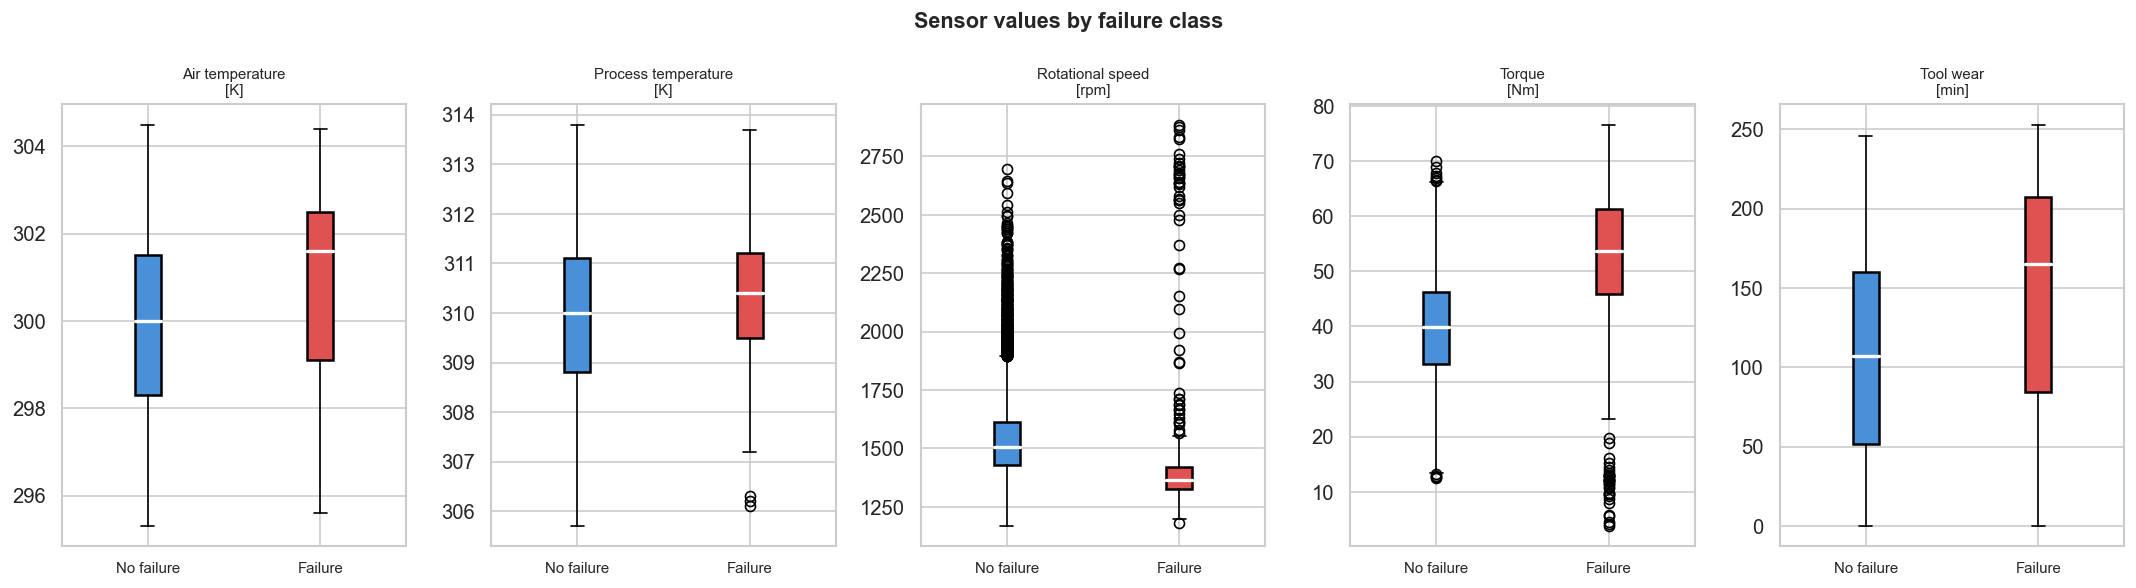

Chart saved as sensor_boxplots.png


In [11]:
# Box plots — easier to see median and spread differences
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(sensor_cols):
    data_groups = [
        df[df['Machine failure'] == 0][col].values,
        df[df['Machine failure'] == 1][col].values
    ]
    bp = axes[i].boxplot(data_groups, patch_artist=True,
                         boxprops=dict(linewidth=1.5),
                         medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor('#4A90D9')
    bp['boxes'][1].set_facecolor('#E05252')
    axes[i].set_xticklabels(['No failure', 'Failure'], fontsize=9)
    axes[i].set_title(col.replace(' [', '\n['), fontsize=9)

fig.suptitle('Sensor values by failure class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sensor_boxplots.png', bbox_inches='tight')
plt.show()
print('Chart saved as sensor_boxplots.png')

---
## Step 6 — Explore Failure Types

Failure type counts:
  TWF:  46  (0.46% of all samples)
  HDF: 115  (1.15% of all samples)
  PWF:  95  (0.95% of all samples)
  OSF:  98  (0.98% of all samples)
  RNF:  19  (0.19% of all samples)


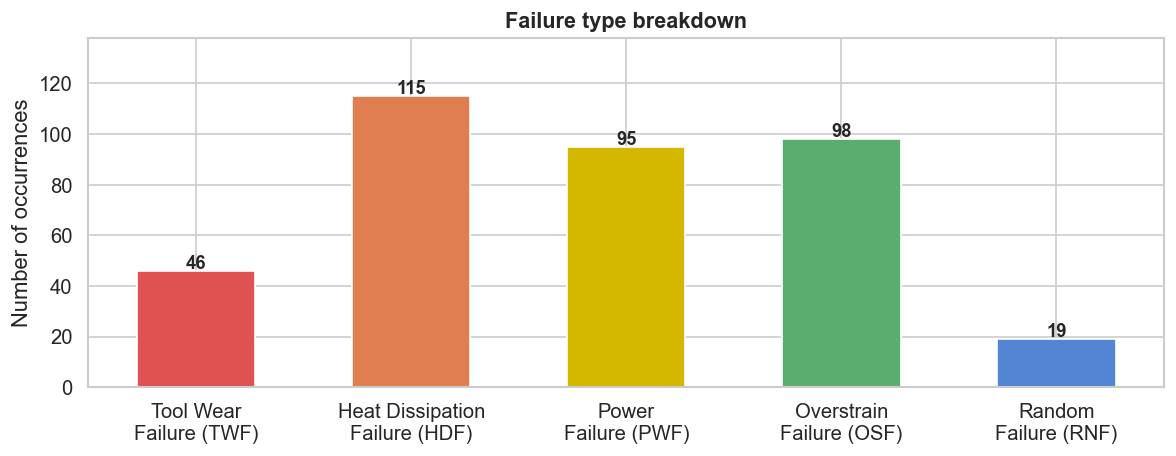

Chart saved as failure_types.png


In [12]:
# How often does each failure type occur?
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_labels = [
    'Tool Wear\nFailure (TWF)',
    'Heat Dissipation\nFailure (HDF)',
    'Power\nFailure (PWF)',
    'Overstrain\nFailure (OSF)',
    'Random\nFailure (RNF)'
]
failure_counts = df[failure_types].sum()

print('Failure type counts:')
for ft, cnt in zip(failure_types, failure_counts):
    print(f'  {ft}: {int(cnt):>3}  ({cnt/len(df)*100:.2f}% of all samples)')

fig, ax = plt.subplots(figsize=(10, 4))
colors_ft = ['#E05252', '#E07E52', '#D4B800', '#5BAD6F', '#5286D4']
bars = ax.bar(failure_labels, failure_counts.values, color=colors_ft,
              edgecolor='white', width=0.55)
for bar, val in zip(bars, failure_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(val)), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Failure type breakdown', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of occurrences')
ax.set_ylim(0, failure_counts.max() * 1.2)
plt.tight_layout()
plt.savefig('failure_types.png', bbox_inches='tight')
plt.show()
print('Chart saved as failure_types.png')

---
## Step 7 — Correlation Heatmap

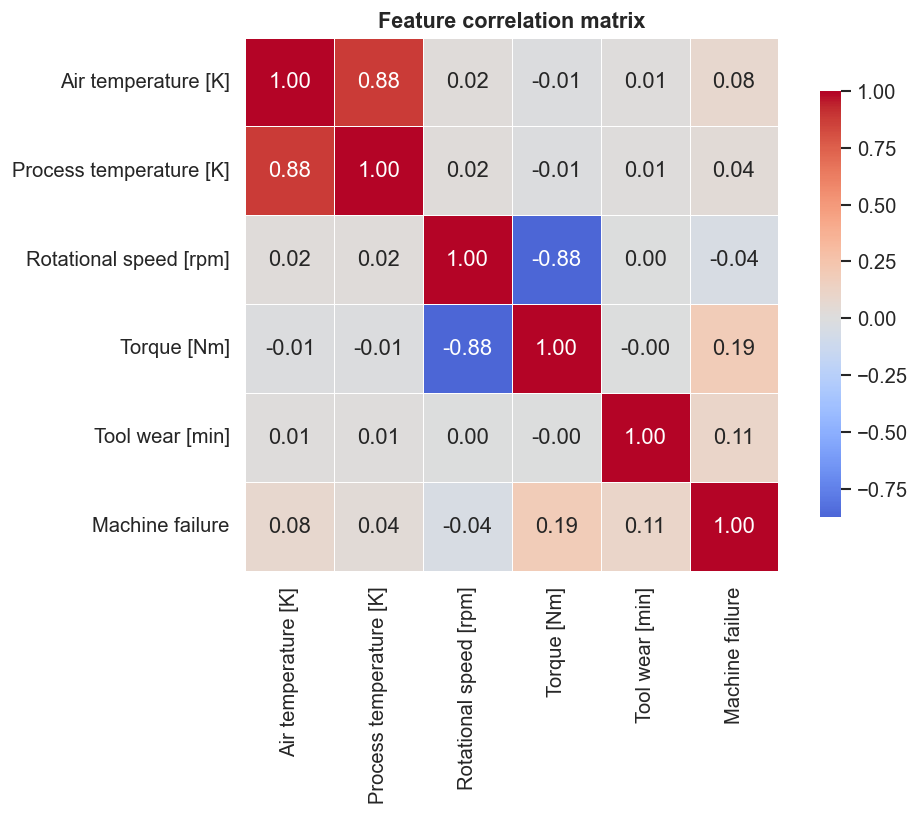

Chart saved as correlation_heatmap.png

Correlation with Machine failure (strongest first):
  Torque [Nm]                         0.1913
  Tool wear [min]                     0.1054
  Air temperature [K]                 0.0826
  Rotational speed [rpm]              0.0442
  Process temperature [K]             0.0359


In [13]:
# Correlation between all numeric features and the target
numeric_cols = sensor_cols + ['Machine failure']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # show lower triangle only
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature correlation matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Chart saved as correlation_heatmap.png')

# Print strongest correlations with the target
print()
print('Correlation with Machine failure (strongest first):')
target_corr = corr_matrix['Machine failure'].drop('Machine failure').abs().sort_values(ascending=False)
for feat, val in target_corr.items():
    print(f'  {feat:<35} {val:.4f}')

---
## Step 8 — Phase 1 Summary & Findings

Run this cell to get a clean summary of everything you discovered.

In [14]:
print('=' * 55)
print(' PHASE 1 SUMMARY — DATASET UNDERSTANDING')
print('=' * 55)

print(f'\n Dataset: AI4I 2020 Predictive Maintenance (UCI)')
print(f' Rows:    {len(df):,}')
print(f' Columns: {len(df.columns)}')

print(f'\n TARGET VARIABLE')
print(f'  Column: Machine failure')
print(f'  No failure: {counts[0]:,}  ({pcts[0]:.1f}%)')
print(f'  Failure:    {counts[1]:,}  ({pcts[1]:.1f}%)')

print(f'\n MISSING VALUES: None')
print(f'\n DATA QUALITY: Good — no cleaning required')

print(f'\n KEY OBSERVATIONS')
print(f'  1. Strong class imbalance (~{counts[0]//counts[1]}:1)')
print(f'     → Will handle with class_weight or SMOTE in Phase 2')
print(f'  2. Torque and rotational speed are negatively correlated')
print(f'     → May create a useful interaction feature: Torque × Speed')
print(f'  3. Tool wear shows visible difference between failure classes')
print(f'     → Strong predictor candidate')
print(f'  4. Air and process temperatures are highly correlated')
print(f'     → May create a delta feature: Process temp - Air temp')

print(f'\n NEXT STEPS (Phase 2)')
print(f'  - Feature engineering (temp delta, power = torque × speed)')
print(f'  - Handle class imbalance')
print(f'  - Encode categorical column (Type: L/M/H)')
print(f'  - Train/test split')
print(f'  - Baseline model')
print('=' * 55)

 PHASE 1 SUMMARY — DATASET UNDERSTANDING

 Dataset: AI4I 2020 Predictive Maintenance (UCI)
 Rows:    10,000
 Columns: 14

 TARGET VARIABLE
  Column: Machine failure
  No failure: 9,661  (96.6%)
  Failure:    339  (3.4%)

 MISSING VALUES: None

 DATA QUALITY: Good — no cleaning required

 KEY OBSERVATIONS
  1. Strong class imbalance (~28:1)
     → Will handle with class_weight or SMOTE in Phase 2
  2. Torque and rotational speed are negatively correlated
     → May create a useful interaction feature: Torque × Speed
  3. Tool wear shows visible difference between failure classes
     → Strong predictor candidate
  4. Air and process temperatures are highly correlated
     → May create a delta feature: Process temp - Air temp

 NEXT STEPS (Phase 2)
  - Feature engineering (temp delta, power = torque × speed)
  - Handle class imbalance
  - Encode categorical column (Type: L/M/H)
  - Train/test split
  - Baseline model


---
## What to save from this phase

Before moving to Phase 2, lets recap what we have saved:

- ✅ `ai4i2020.csv` — raw dataset
- ✅ `class_distribution.png` — for your README / LinkedIn post
- ✅ `sensor_distributions.png`
- ✅ `sensor_boxplots.png`
- ✅ `failure_types.png`
- ✅ `correlation_heatmap.png`
- ✅ This notebook committed to your GitHub repo

---

> **Phase 2 preview:** We will engineer new features, handle class imbalance,  
> encode the `Type` column, and train your first baseline model. 🚀